<a href="https://colab.research.google.com/github/sdbileg/alpha/blob/main/StrategiesLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Optional: Improve visual styling for plots
plt.style.use('seaborn-v0_8-darkgrid') if 'seaborn-v0_8-darkgrid' in plt.style.available else plt.style.use('ggplot')


def get_clean_data(ticker: str, period: str = "3y") -> pd.DataFrame:
    """Downloads and formats historical price data for a single ticker."""
    raw = yf.download(ticker, period=period, progress=False)

    # Handle yfinance multi-index column outputs if present
    if isinstance(raw.columns, pd.MultiIndex):
        price_series = raw["Close"].iloc[:, 0]
    else:
        price_series = raw["Close"]

    df = pd.DataFrame({"Close": price_series.dropna()})
    df["Return"] = np.log(df["Close"] / df["Close"].shift(1))
    return df


def calculate_metrics(df: pd.DataFrame, strategy_col: str = "Strategy") -> dict:
    """Calculates key performance and risk metrics for a strategy."""
    total_buy_hold = (df["Cum_Buy_Hold"].iloc[-1] - 1) * 100
    total_strategy = (df[f"Cum_{strategy_col}"].iloc[-1] - 1) * 100

    # Annualized Sharpe Ratio (assuming 252 trading days, 0% risk-free rate)
    strat_returns = df[strategy_col].dropna()
    mean_ret = strat_returns.mean() * 252
    volatility = strat_returns.std() * np.sqrt(252)
    sharpe = mean_ret / volatility if volatility != 0 else 0.0

    # Maximum Drawdown
    equity = df[f"Cum_{strategy_col}"]
    peak = equity.cummax()
    drawdown = (equity - peak) / peak
    max_dd = drawdown.min() * 100

    # Days invested
    active_days = (df["Position"] != 0).sum()

    return {
        "Buy & Hold Return": f"{total_buy_hold:.2f}%",
        "Strategy Return": f"{total_strategy:.2f}%",
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown": f"{max_dd:.2f}%",
        "Days Invested": f"{active_days} / {len(df)} ({active_days/len(df)*100:.1f}%)"
    }


def plot_performance(df: pd.DataFrame, ticker: str, strategy_name: str = "Strategy"):
    """Plots equity curve comparisons."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df["Cum_Buy_Hold"], label=f"{ticker} Buy & Hold", alpha=0.5, linestyle="--")
    ax.plot(df.index, df[f"Cum_{strategy_name}"], label=f"{strategy_name}", linewidth=1.8)

    ax.set_title(f"{ticker} — {strategy_name} vs. Benchmark", fontsize=12, fontweight="bold")
    ax.set_ylabel("Growth Multiplier ($1 Initial)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- CONFIGURATION ---
TICKER = "NTRA"
LOOKBACK = "3y"

# Download cleaned price data
df = get_clean_data(TICKER, period=LOOKBACK)
print(f"Loaded {len(df)} rows of data for {TICKER}.")
df.tail(3)

/tmp/ipykernel_6644/1834651830.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, period=period, progress=False)


Loaded 753 rows of data for NTRA.


,Close,Return
Date,,
2026-07-28,252.220001,-0.022774
2026-07-29,253.820007,0.006324
2026-07-30,269.660004,0.060537


In [ ]:
# --- INDICATORS ---
df["SMA200"] = df["Close"].rolling(window=200).mean()
df["EMA10"] = df["Close"].ewm(span=10, adjust=False).mean()
df["EMA30"] = df["Close"].ewm(span=30, adjust=False).mean()

# --- CONDITIONS & POSITIONING ---
macro_bullish = df["Close"] > df["SMA200"]
fast_trigger = df["EMA10"] > df["EMA30"]

# 1 = Long, 0 = Cash
df["Position"] = np.where(macro_bullish & fast_trigger, 1, 0)

# Shift position by 1 day to prevent look-ahead bias
df["Strategy"] = df["Position"].shift(1) * df["Return"]

# Clean missing initial rolling rows
df.dropna(inplace=True)

# Calculate Equity Curves
df["Cum_Buy_Hold"] = df["Return"].cumsum().apply(np.exp)
df["Cum_Strategy"] = df["Strategy"].cumsum().apply(np.exp)

=== NTRA PERFORMANCE REPORT ===
Buy & Hold Return   : 160.97%
Strategy Return     : 75.91%
Sharpe Ratio        : 0.73
Max Drawdown        : -32.33%
Days Invested       : 400 / 554 (72.2%)


KeyError: 'Cum_Hybrid SMA/EMA'

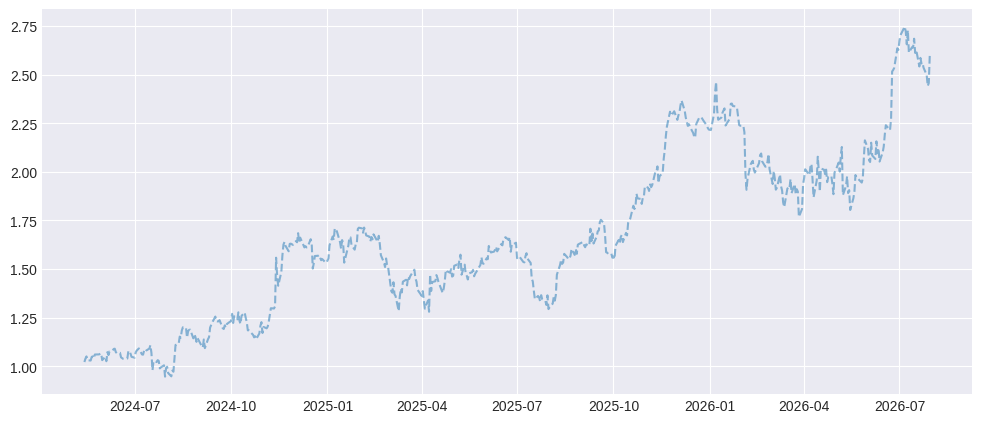

In [ ]:
# Print Performance Summary
metrics = calculate_metrics(df, strategy_col="Strategy")

print(f"=== {TICKER} PERFORMANCE REPORT ===")
for metric, value in metrics.items():
    print(f"{metric:<20}: {value}")

# Plot Results
plot_performance(df, ticker=TICKER, strategy_name="Hybrid SMA/EMA")

In [ ]:
# How to use this workflow daily:
Test a new stock: Change TICKER = "PYPL" in Cell 2 to "AAPL", "MSFT", or "QQQ", then click Run All.

Modify rules: Tweak the indicators or logic in Cell 3 without re-writing the math or plotting code.

Save changes: Hit Ctrl + S (Cmd + S on Mac) regularly to keep your workspace updated.

In [ ]:
import os
print("Your notebook is saved here:")
print(os.path.abspath("."))

Your notebook is saved here:
C:\Users\sdbil
